In [ ]:
# script to compare the correlations of predictions across each prediction type #
# ie panel one - are we identifying the same functional variants by effect size #
# updates from V1 (archived):
# tabix filtered predictions are now from the correct BED file

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm import tqdm
import torch
from scipy import stats
import numpy as np
import matplotlib
from tqdm import tqdm
import os
import pybedtools

In [2]:
# open the current DF for analyses, everything is already combined here
promoter_preds_df = pd.read_csv('processed_data/mpac.250bp.promoter.preds.with.annotations.parm.act.promoterAI.parm.sat.mut.v2.tsv', sep = '\t')

In [3]:
# add mean mpac skew :/
promoter_preds_df.loc[:, 'mpac_mean_skew'] = [np.mean([k,h,s]) for k,h,s in zip(promoter_preds_df['k562_skew_pred'], promoter_preds_df['hepg2_skew_pred'], promoter_preds_df['sknsh_skew_pred'])]
# add max mpac skew
promoter_preds_df.loc[:, 'mpac_max_skew'] = [max([k,h,s], key=abs) for k,h,s in zip(promoter_preds_df['k562_skew_pred'], promoter_preds_df['hepg2_skew_pred'], promoter_preds_df['sknsh_skew_pred'])]
# add max parm skew
promoter_preds_df.loc[:, 'parm_max_skew'] = [max([k,h], key=abs) for k,h in zip(promoter_preds_df['parm_k562_pred'], promoter_preds_df['parm_hepg2_pred'])]
# add ID for merging wth phyloP scores
promoter_preds_df.loc[:, 'var_id'] = [(':').join([chrom, str(pos), ref, alt]) for chrom, pos, ref, alt in zip(promoter_preds_df['chrom'], promoter_preds_df['pos'], promoter_preds_df['ref'], promoter_preds_df['alt'])]

In [4]:
# open phyloP annotated variants and add phyloP scores
phylo470 = pd.read_csv('processed_data/mpac.250bp.promoter.preds.with.annotations.parm.act.promoterAI.parm.sat.mut4.phyloP.annotated.v2.vcf', sep = '\t', comment = '#', header = None)
# drop missing values
phylo470 = phylo470[phylo470[7] != '.']
# build dictionary for adding 
phylo470_dict = dict(zip([(':').join([chrom, str(pos), ref, alt])for chrom, pos, ref, alt in zip(phylo470[0], 
                                                                                                 phylo470[1], 
                                                                                                 phylo470[3], 
                                                                                                 phylo470[4])],
                     [float(i.split('=')[-1]) for i in phylo470[7]]))
# add 470-way phyloP score
promoter_preds_df.loc[:, 'phyloP_470'] = [phylo470_dict.get(i) for i in promoter_preds_df['var_id']]

In [5]:
# add 241 way phyloP scores
phylo241 = pd.read_csv('processed_data/mpac.250bp.promoter.preds.with.annotations.parm.act.promoterAI.parm.sat.mut4.phyloP.annotated.241.mamm.v2.vcf', sep = '\t', comment = '#', header = None)
# drop missing values
phylo241 = phylo241[phylo241[7] != '.']
# build dictionary for adding 
phylo241_dict = dict(zip([(':').join([chrom, str(pos), ref, alt])for chrom, pos, ref, alt in zip(phylo241[0], 
                                                                                                 phylo241[1], 
                                                                                                 phylo241[3], 
                                                                                                 phylo241[4])],
                     [float(i.split('=')[-1]) for i in phylo241[7]]))
# add 241-way phyloP score
promoter_preds_df.loc[:, 'phyloP_241'] = [phylo241_dict.get(i) for i in promoter_preds_df['var_id']]

In [6]:
# first lets do all correlations at the nucleotide level
# some positions are NAs in promoterAI, we will drop those for this analysis
# we'll also drop those predictions without phyloP scores
# filter for those
promoterAI_filtered_preds = promoter_preds_df.dropna().copy()
# drop multiple instances of the same variants in overlapping promoters
# break out the merge ID to a groupby ID for taking the mean of all three mutations at each position
promoterAI_filtered_preds.loc[:, 'groupby_id'] = [(':').join(i.split(':')[:2]) for i in promoterAI_filtered_preds['var_id']]
promoterAI_filtered_preds = promoterAI_filtered_preds.drop_duplicates(subset='var_id')

In [11]:
print(f'there are {len(promoterAI_filtered_preds)} unique predictions shared across all models')
print(f'there are {len(promoterAI_filtered_preds['id'].unique())} unique promoters shared across all models')
print(f'there are {len(promoterAI_filtered_preds['groupby_id'].unique())} unique positions shared across all models')

there are 10371378 unique predictions shared across all models
there are 15881 unique promoters shared across all models
there are 3457126 unique positions shared across all models


In [18]:
# compute correlations for each mpac skew prediction
# mpac vs. promoterAI
labels = []
labels_parm = []
proAI_corrs = []
parm_hepg2_corrs = []
parm_k562_corrs = []
parm_mean_corrs = []
parm_max_corrs = []
parm_proAI_corrs = []
# phyloP
# pearson
phylo_labels = []
phyloP_241_corrs = []
phyloP_470_corrs = []
# spearman
phylo_labels_spear = []
phyloP_241_corrs_spear = []
phyloP_470_corrs_spear = []
# compute correlations for promoterAI
for skew in ['k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred', 'mpac_mean_skew', 'mpac_max_skew']:
    # update labels list
    labels.append(skew)
    # calculate correlation for that mpac column
    # promoterAI
    proAI_corrs.append(round(stats.pearsonr(x=promoterAI_filtered_preds[skew], y=promoterAI_filtered_preds['promoterAI_score'])[0], 2))
# compute correlations for k562_parm predictions
for skew in ['k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred', 'mpac_mean_skew', 'mpac_max_skew']:
    # calculate correlation for that mpac column
    # promoterAI
    parm_k562_corrs.append(round(stats.pearsonr(x=promoterAI_filtered_preds[skew], y=promoterAI_filtered_preds['parm_k562_pred'])[0], 2))
# compute correlations for hepg2_parm predictions
for skew in ['k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred', 'mpac_mean_skew', 'mpac_max_skew']:
    # calculate correlation for that mpac column
    # promoterAI
    parm_hepg2_corrs.append(round(stats.pearsonr(x=promoterAI_filtered_preds[skew], y=promoterAI_filtered_preds['parm_hepg2_pred'])[0], 2))
# compute correlations for mean_parm predictions
for skew in ['k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred', 'mpac_mean_skew', 'mpac_max_skew']:
    # calculate correlation for that mpac column
    # promoterAI
    parm_mean_corrs.append(round(stats.pearsonr(x=promoterAI_filtered_preds[skew], y=promoterAI_filtered_preds['parm_mean_pred'])[0], 2))
# compute correlations for max_parm predictions
for skew in ['k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred', 'mpac_mean_skew', 'mpac_max_skew']:
    # calculate correlation for that mpac column
    # promoterAI
    parm_max_corrs.append(round(stats.pearsonr(x=promoterAI_filtered_preds[skew], y=promoterAI_filtered_preds['parm_max_skew'])[0], 2))
# compute correlations for parm vs. promoterAI
for skew in ['parm_k562_pred', 'parm_hepg2_pred', 'parm_mean_pred', 'parm_max_skew']:
    # update other label list
    labels_parm.append(skew)
    # calculate correlation for that parm column
    # promoterAI
    parm_proAI_corrs.append(round(stats.pearsonr(x=promoterAI_filtered_preds[skew], y=promoterAI_filtered_preds['promoterAI_score'])[0], 2))
# compute correlations for everything vs. 241-way phyloP
for skew in ['k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred', 'mpac_mean_skew', 'mpac_max_skew', # MPAC
             'parm_k562_pred', 'parm_hepg2_pred', 'parm_mean_pred', 'parm_max_skew', # PARM
             'promoterAI_score']: # promoterAI
    phylo_labels.append(skew)
    phyloP_241_corrs.append(round(stats.pearsonr(x=[abs(i) for i in promoterAI_filtered_preds[skew]], y=promoterAI_filtered_preds['phyloP_241'])[0], 2))
# compute correlations for everything vs. 470-way phyloP
for skew in ['k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred', 'mpac_mean_skew', 'mpac_max_skew', # MPAC
             'parm_k562_pred', 'parm_hepg2_pred', 'parm_mean_pred', 'parm_max_skew', # PARM
             'promoterAI_score']: # promoterAI
    phylo_labels.append(skew)
    phyloP_470_corrs.append(round(stats.pearsonr(x=[abs(i) for i in promoterAI_filtered_preds[skew]], y=promoterAI_filtered_preds['phyloP_470'])[0], 2))
# compute correlations for everything vs. 241-way phyloP
# spearman - stephen style
for skew in ['k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred', 'mpac_mean_skew', 'mpac_max_skew', # MPAC
             'parm_k562_pred', 'parm_hepg2_pred', 'parm_mean_pred', 'parm_max_skew', # PARM
             'promoterAI_score']: # promoterAI
    phylo_labels_spear.append(skew)
    phyloP_241_corrs_spear.append(round(stats.spearmanr(a=[abs(i) for i in promoterAI_filtered_preds[skew]], b=[max(0,i) for i in promoterAI_filtered_preds['phyloP_241']])[0], 2))
# compute correlations for everything vs. 470-way phyloP
# spearman - stephen style
for skew in ['k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred', 'mpac_mean_skew', 'mpac_max_skew', # MPAC
             'parm_k562_pred', 'parm_hepg2_pred', 'parm_mean_pred', 'parm_max_skew', # PARM
             'promoterAI_score']: # promoterAI
    phylo_labels_spear.append(skew)
    phyloP_470_corrs_spear.append(round(stats.spearmanr(a=[abs(i) for i in promoterAI_filtered_preds[skew]], b=[max(0,i) for i in promoterAI_filtered_preds['phyloP_470']])[0], 2))

/tmp/ipykernel_4164780/1017959054.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.87, 1]) # Adjust rect to leave space for colorbar


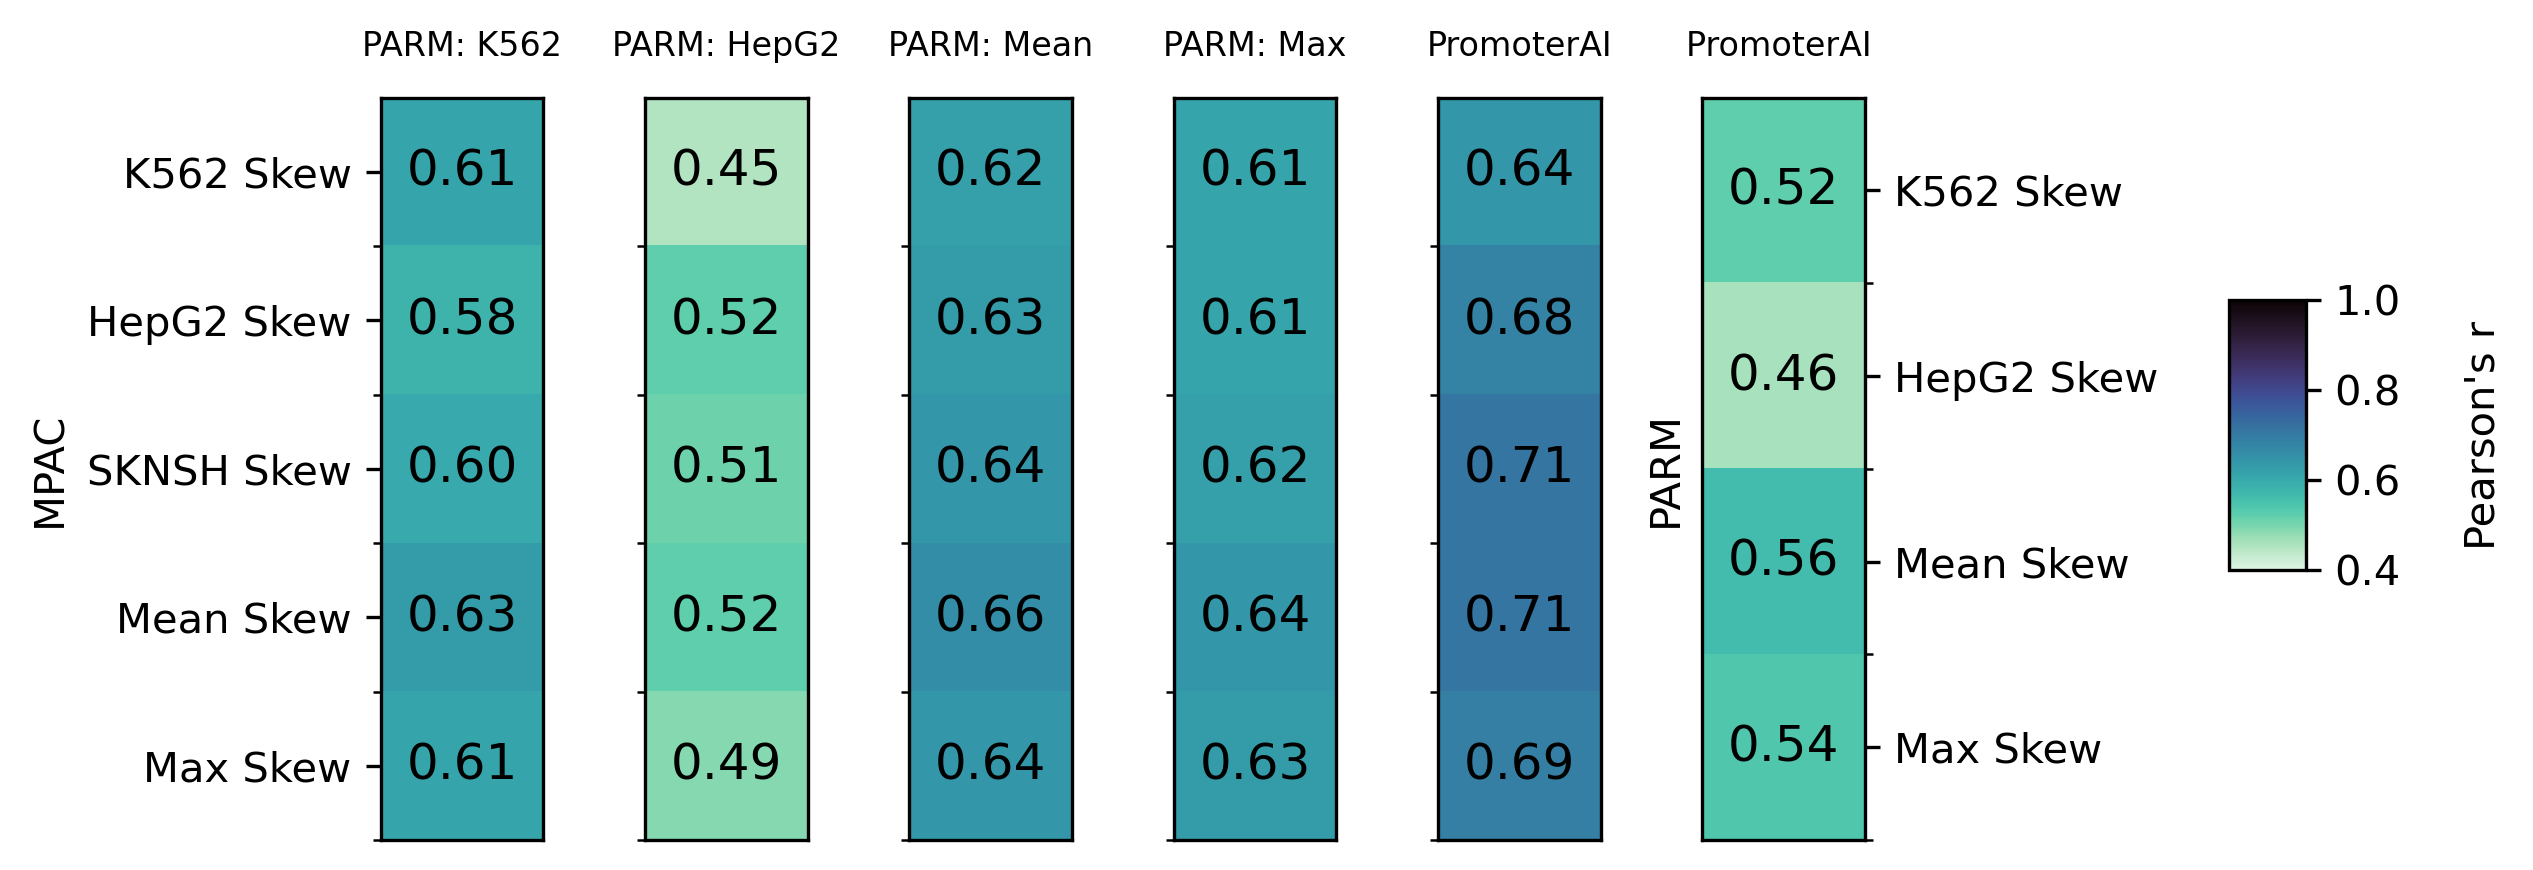

In [60]:
# Combine all data into a dictionary
labels = ['K562 Skew', 'HepG2 Skew', 'SKNSH Skew', 'Mean Skew', 'Max Skew']
labels_parm = ['K562 Skew', 'HepG2 Skew', 'Mean Skew', 'Max Skew']
data = {
    "PARM: K562": pd.Series(parm_k562_corrs, index=labels),
    "PARM: HepG2": pd.Series(parm_hepg2_corrs, index=labels),
    "PARM: Mean": pd.Series(parm_mean_corrs, index=labels),
    "PARM: Max" : pd.Series(parm_max_corrs, index=labels),
    "PromoterAI": pd.Series(proAI_corrs, index=labels),
    "PromoterAI ": pd.Series(parm_proAI_corrs, index=labels_parm)
}
model_names = list(data.keys())

fig, axes = plt.subplots(1, 6, figsize=(8.5, 3), dpi=300)

cmap = 'mako_r'
vmin = 0.4
vmax = 1.0
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# 4. Loop through all 5 models and axes
for i, model_name in enumerate(model_names):
    ax = axes[i]
    correlations = data[model_name]
    heatmap_data = correlations.to_numpy().reshape(-1, 1)
    
    im = ax.imshow(heatmap_data, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_title(model_name, fontsize=8, pad=10)
    ax.set_xticks([])
    
    for j, corr in enumerate(correlations):
        # Adjusted text color for potentially lighter background with 'mako_r'
        text_color = "black"
        ax.text(0, j, f'{corr:.2f}', ha='center', va='center', color=text_color, fontsize=12)

axes[0].set_yticks(np.arange(len(labels)))
axes[0].set_yticklabels(labels, fontsize=10)
axes[0].set_ylabel('MPAC', fontsize=10)
axes[0].set_yticks(np.arange(len(labels)) + 0.5, minor=True)

for i in range(1, 5):
    axes[i].set_yticklabels([])
    axes[i].set_yticks(np.arange(len(labels)) + 0.5, minor=True)
    # Ensure they don't have major ticks if yticklabels are empty
    axes[i].tick_params(axis='y', length=0)

axes[5].set_yticks(np.arange(len(labels_parm)))
axes[5].set_yticklabels(labels_parm, fontsize=10)
axes[5].yaxis.tick_right() # Move labels to the right for clarity
axes[5].set_yticks(np.arange(len(labels_parm)) + 0.5, minor=True)
axes[5].set_ylabel('PARM', size=10)

# 6. Add a single, shared colorbar
fig.subplots_adjust(right=0.85) 

cbar_ax = fig.add_axes([0.88, 0.35, 0.03, 0.3])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Pearson's r", fontsize=10, labelpad=15) # labelpad moves the label further away

# Ensure tight layout adjusts everything properly
plt.tight_layout(rect=[0, 0, 0.87, 1]) # Adjust rect to leave space for colorbar
plt.savefig('plots/mpac_parm_promoterAI_promoter_prediction_correlations_heatmap_v2.pdf')
plt.show()

In [20]:
lenPreds = len(promoterAI_filtered_preds)
# calculate the concordance rate of predictions
# mpac v proAI
# k562
k_mpac_proAI_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['k562_skew_pred'], promoterAI_filtered_preds['promoterAI_score'])]).sum() / lenPreds
# hepg2
h_mpac_proAI_conc = pd.Series([1 if h > 0 and p > 0 or h < 0 and p < 0 else 0 for h, p in zip(promoterAI_filtered_preds['hepg2_skew_pred'], promoterAI_filtered_preds['promoterAI_score'])]).sum() / lenPreds
# sknsh
s_mpac_proAI_conc = pd.Series([1 if s > 0 and p > 0 or s < 0 and p < 0 else 0 for s, p in zip(promoterAI_filtered_preds['sknsh_skew_pred'], promoterAI_filtered_preds['promoterAI_score'])]).sum() / lenPreds
# mean
mean_mpac_proAI_conc = pd.Series([1 if mpac > 0 and p > 0 or mpac < 0 and p < 0 else 0 for mpac, p in zip(promoterAI_filtered_preds['mpac_mean_skew'], promoterAI_filtered_preds['promoterAI_score'])]).sum() / lenPreds
# max
max_mpac_proAI_conc = pd.Series([1 if mpac > 0 and p > 0 or mpac < 0 and p < 0 else 0 for mpac, p in zip(promoterAI_filtered_preds['mpac_max_skew'], promoterAI_filtered_preds['promoterAI_score'])]).sum() / lenPreds
# mpac v PARM: K562
# k562
k_mpac_parm_k_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['k562_skew_pred'], promoterAI_filtered_preds['parm_k562_pred'])]).sum() / lenPreds
# hepg2
h_mpac_parm_k_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['hepg2_skew_pred'], promoterAI_filtered_preds['parm_k562_pred'])]).sum() / lenPreds
# sknsh
s_mpac_parm_k_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['sknsh_skew_pred'], promoterAI_filtered_preds['parm_k562_pred'])]).sum() / lenPreds
# mean
mean_mpac_parm_k_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['mpac_mean_skew'], promoterAI_filtered_preds['parm_k562_pred'])]).sum() / lenPreds
# max
max_mpac_parm_k_conc = pd.Series([1 if mpac > 0 and p > 0 or mpac < 0 and p < 0 else 0 for mpac, p in zip(promoterAI_filtered_preds['mpac_max_skew'], promoterAI_filtered_preds['parm_k562_pred'])]).sum() / lenPreds
# mpac v PARM: HepG2
# k562
k_mpac_parm_h_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['k562_skew_pred'], promoterAI_filtered_preds['parm_hepg2_pred'])]).sum() / lenPreds
# hepg2
h_mpac_parm_h_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['hepg2_skew_pred'], promoterAI_filtered_preds['parm_hepg2_pred'])]).sum() / lenPreds
# sknsh
s_mpac_parm_h_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['sknsh_skew_pred'], promoterAI_filtered_preds['parm_hepg2_pred'])]).sum() / lenPreds
# mean
mean_mpac_parm_h_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['mpac_mean_skew'], promoterAI_filtered_preds['parm_hepg2_pred'])]).sum() / lenPreds
# max
max_mpac_parm_h_conc = pd.Series([1 if mpac > 0 and p > 0 or mpac < 0 and p < 0 else 0 for mpac, p in zip(promoterAI_filtered_preds['mpac_max_skew'], promoterAI_filtered_preds['parm_hepg2_pred'])]).sum() / lenPreds
# mpac v PARM: Mean
# k562
k_mpac_parm_mean_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['k562_skew_pred'], promoterAI_filtered_preds['parm_mean_pred'])]).sum() / lenPreds
# hepg2
h_mpac_parm_mean_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['hepg2_skew_pred'], promoterAI_filtered_preds['parm_mean_pred'])]).sum() / lenPreds
# sknsh
s_mpac_parm_mean_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['sknsh_skew_pred'], promoterAI_filtered_preds['parm_mean_pred'])]).sum() / lenPreds
# mean
mean_mpac_parm_mean_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['mpac_mean_skew'], promoterAI_filtered_preds['parm_mean_pred'])]).sum() / lenPreds
# max
max_mpac_parm_mean_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['mpac_max_skew'], promoterAI_filtered_preds['parm_mean_pred'])]).sum() / lenPreds
# mpac v PARM: Max
# k562
k_mpac_parm_max_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['k562_skew_pred'], promoterAI_filtered_preds['parm_max_skew'])]).sum() / lenPreds
# hepg2
h_mpac_parm_max_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['hepg2_skew_pred'], promoterAI_filtered_preds['parm_max_skew'])]).sum() / lenPreds
# sknsh
s_mpac_parm_max_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['sknsh_skew_pred'], promoterAI_filtered_preds['parm_max_skew'])]).sum() / lenPreds
# mean
mean_mpac_parm_max_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['mpac_mean_skew'], promoterAI_filtered_preds['parm_max_skew'])]).sum() / lenPreds
# max
max_mpac_parm_max_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['mpac_max_skew'], promoterAI_filtered_preds['parm_max_skew'])]).sum() / lenPreds
# PARM vs. promoterAI
# k562
k_parm_pAI_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['parm_k562_pred'], promoterAI_filtered_preds['promoterAI_score'])]).sum() / lenPreds
# hepg2
h_parm_pAI_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['parm_hepg2_pred'], promoterAI_filtered_preds['promoterAI_score'])]).sum() / lenPreds
# mean
mean_parm_pAI_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['parm_mean_pred'], promoterAI_filtered_preds['promoterAI_score'])]).sum() / lenPreds
# max
max_parm_pAI_conc = pd.Series([1 if k > 0 and p > 0 or k < 0 and p < 0 else 0 for k, p in zip(promoterAI_filtered_preds['parm_max_skew'], promoterAI_filtered_preds['promoterAI_score'])]).sum() / lenPreds

/tmp/ipykernel_4164780/272537305.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.87, 1]) # Adjust rect to leave space for colorbar


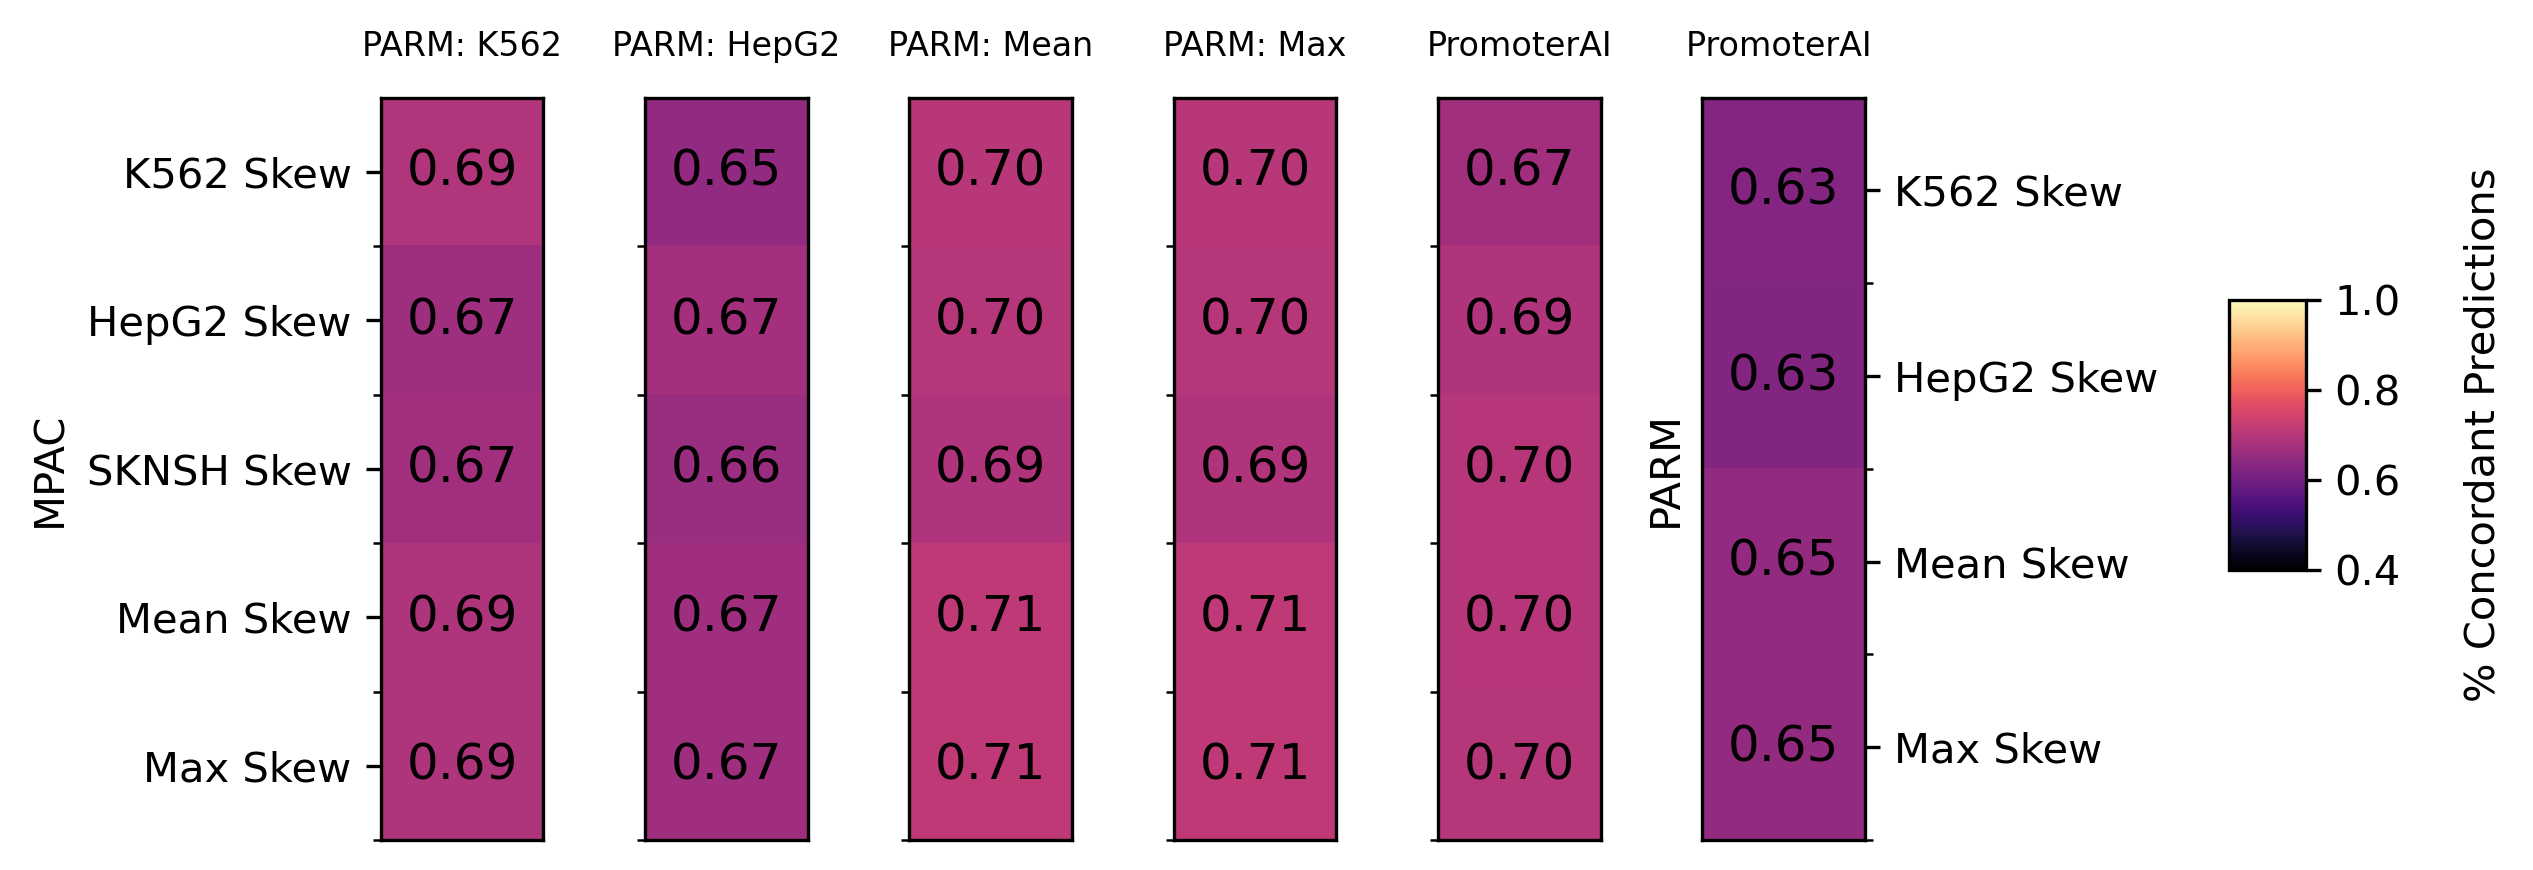

In [61]:
labels = ['K562 Skew', 'HepG2 Skew', 'SKNSH Skew', 'Mean Skew', 'Max Skew']
labels_parm = ['K562 Skew', 'HepG2 Skew', 'Mean Skew', 'Max Skew']
data = {
    "PARM: K562": pd.Series([k_mpac_parm_k_conc, h_mpac_parm_k_conc, s_mpac_parm_k_conc, mean_mpac_parm_k_conc, max_mpac_parm_k_conc], index=labels),
    "PARM: HepG2": pd.Series([k_mpac_parm_h_conc, h_mpac_parm_h_conc, s_mpac_parm_h_conc, mean_mpac_parm_h_conc, max_mpac_parm_h_conc], index=labels),
    "PARM: Mean": pd.Series([k_mpac_parm_mean_conc, h_mpac_parm_mean_conc, s_mpac_parm_mean_conc, mean_mpac_parm_mean_conc, max_mpac_parm_mean_conc], index=labels),
    "PARM: Max" : pd.Series([k_mpac_parm_max_conc, h_mpac_parm_max_conc, s_mpac_parm_max_conc, mean_mpac_parm_max_conc, max_mpac_parm_max_conc], index=labels),
    "PromoterAI": pd.Series([k_mpac_proAI_conc, h_mpac_proAI_conc, s_mpac_proAI_conc, mean_mpac_proAI_conc, max_mpac_proAI_conc], index=labels),
    "PromoterAI ": pd.Series([k_parm_pAI_conc, h_parm_pAI_conc, mean_parm_pAI_conc, max_parm_pAI_conc], index=labels_parm)
}
model_names = list(data.keys())

fig, axes = plt.subplots(1, 6, figsize=(8.5, 3), dpi=300)

cmap = 'magma'
vmin = 0.4
vmax = 1.0
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# 4. Loop through all 5 models and axes
for i, model_name in enumerate(model_names):
    ax = axes[i]
    correlations = data[model_name]
    heatmap_data = correlations.to_numpy().reshape(-1, 1)
    
    im = ax.imshow(heatmap_data, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_title(model_name, fontsize=8, pad=10)
    ax.set_xticks([])
    
    for j, corr in enumerate(correlations):
        # Adjusted text color for potentially lighter background with 'mako_r'
        text_color = "black"
        ax.text(0, j, f'{corr:.2f}', ha='center', va='center', color=text_color, fontsize=12)
axes[0].set_yticks(np.arange(len(labels)))
axes[0].set_yticklabels(labels, fontsize=10)
axes[0].set_ylabel('MPAC', fontsize=10)
axes[0].set_yticks(np.arange(len(labels)) + 0.5, minor=True)
for i in range(1, 5):
    axes[i].set_yticklabels([])
    axes[i].set_yticks(np.arange(len(labels)) + 0.5, minor=True)
    # Ensure they don't have major ticks if yticklabels are empty
    axes[i].tick_params(axis='y', length=0)

axes[5].set_yticks(np.arange(len(labels_parm)))
axes[5].set_yticklabels(labels_parm, fontsize=10)
axes[5].yaxis.tick_right() # Move labels to the right for clarity
axes[5].set_yticks(np.arange(len(labels_parm)) + 0.5, minor=True)
axes[5].set_ylabel('PARM', size=10)

# 6. Add a single, shared colorbar
fig.subplots_adjust(right=0.85) 

cbar_ax = fig.add_axes([0.88, 0.35, 0.03, 0.3])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("% Concordant Predictions", fontsize=10, labelpad=15) # labelpad moves the label further away

# Ensure tight layout adjusts everything properly
plt.tight_layout(rect=[0, 0, 0.87, 1]) # Adjust rect to leave space for colorbar
plt.savefig('plots/mpac_parm_promoterAI_promoter_prediction_concordance_heatmap_v2.pdf')
plt.show()

In [22]:
mean_mpac_proAI_conc

np.float64(0.7002119679757116)

In [23]:
# get the percentile of an absolute skew of 0.5 for calling promoterAI and PARM emVars
mpac_emvar_quantile = stats.percentileofscore([abs(i) for i in promoterAI_filtered_preds['mpac_mean_skew']], .5) / 100
print(mpac_emvar_quantile)
# get the absolute skew thresholds for each prediction method
# promoterAI
proAI_emVar_thresh = np.quantile([abs(i) for i in promoterAI_filtered_preds['promoterAI_score']], mpac_emvar_quantile)
print(proAI_emVar_thresh)
# PARM
PARM_emVar_thresh = np.quantile([abs(i) for i in promoterAI_filtered_preds['parm_mean_pred']], mpac_emvar_quantile)
print(PARM_emVar_thresh)

0.9378530027543109
0.298
0.1294261133898446


In [24]:
# break out the merge ID to a groupby ID for taking the mean of all three mutations at each position
promoterAI_filtered_preds.loc[:, 'groupby_id'] = [(':').join(i.split(':')[:2]) for i in promoterAI_filtered_preds['var_id']]
# groupby mean
proAI_filtered_mean_groupby = promoterAI_filtered_preds.filter(['groupby_id', 'k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred', 'mpac_mean_skew', 'mpac_max_skew',
                                                                'parm_hepg2_pred', 'parm_k562_pred', 'parm_mean_pred', 'parm_max_skew',
                                                                'promoterAI_score', 'phyloP_470', 'phyloP_241']).groupby('groupby_id').mean().reset_index()

In [25]:
# call emVars for each MPAC cell type, parm cell type, means, and promoterAI
### MPAC ###
# k562
proAI_filtered_mean_groupby.loc[:,'mpac_k562_emVar'] = [1 if abs(i) > 0.5 else 0 for i in proAI_filtered_mean_groupby['k562_skew_pred']]
# hepg2
proAI_filtered_mean_groupby.loc[:,'mpac_hepg2_emVar'] = [1 if abs(i) > 0.5 else 0 for i in proAI_filtered_mean_groupby['hepg2_skew_pred']]
# sknsh
proAI_filtered_mean_groupby.loc[:,'mpac_sknsh_emVar'] = [1 if abs(i) > 0.5 else 0 for i in proAI_filtered_mean_groupby['sknsh_skew_pred']]
# mean
proAI_filtered_mean_groupby.loc[:,'mpac_mean_emVar'] = [1 if abs(i) > 0.5 else 0 for i in proAI_filtered_mean_groupby['mpac_mean_skew']]
# max
proAI_filtered_mean_groupby.loc[:,'mpac_max_emVar'] = [1 if abs(i) > 0.5 else 0 for i in proAI_filtered_mean_groupby['mpac_max_skew']]
### PARM ###
# k562
proAI_filtered_mean_groupby.loc[:, 'parm_k562_emVar'] = [1 if abs(i) > 0.1 else 0 for i in proAI_filtered_mean_groupby['parm_k562_pred']]
# hepg2
proAI_filtered_mean_groupby.loc[:, 'parm_hepg2_emVar'] = [1 if abs(i) > 0.1 else 0 for i in proAI_filtered_mean_groupby['parm_hepg2_pred']]
# mean
proAI_filtered_mean_groupby.loc[:, 'parm_mean_emVar'] = [1 if abs(i) > 0.1 else 0 for i in proAI_filtered_mean_groupby['parm_mean_pred']]
# max
proAI_filtered_mean_groupby.loc[:, 'parm_max_emVar'] = [1 if abs(i) > 0.1 else 0 for i in proAI_filtered_mean_groupby['parm_max_skew']]
### promterAI ###
proAI_filtered_mean_groupby.loc[:, 'promoterAI_emVar'] = [1 if abs(i) > proAI_emVar_thresh else 0 for i in proAI_filtered_mean_groupby['promoterAI_score']]

In [26]:
proAI_filtered_mean_groupby.head()

,groupby_id,k562_skew_pred,hepg2_skew_pred,sknsh_skew_pred,mpac_mean_skew,mpac_max_skew,parm_hepg2_pred,parm_k562_pred,parm_mean_pred,parm_max_skew,...,mpac_k562_emVar,mpac_hepg2_emVar,mpac_sknsh_emVar,mpac_mean_emVar,mpac_max_emVar,parm_k562_emVar,parm_hepg2_emVar,parm_mean_emVar,parm_max_emVar,promoterAI_emVar
0,chr10:100009948,-0.765596,-0.489724,-0.539004,-0.598108,-0.765596,-0.057361,-0.033407,-0.045384,-0.057361,...,1,0,1,1,1,0,0,0,0,0
1,chr10:100009949,-0.679008,-0.300394,-0.275782,-0.418395,-0.444360,-0.033512,-0.027542,-0.030527,-0.032488,...,1,0,0,0,0,0,0,0,0,0
2,chr10:100009950,-0.505355,-0.210674,-0.147546,-0.287858,-0.465650,-0.039495,-0.045833,-0.042664,-0.050866,...,1,0,0,0,0,0,0,0,0,0
3,chr10:100009951,-1.013073,-0.626431,-0.690968,-0.776824,-1.013073,-0.073669,-0.051701,-0.062685,-0.074114,...,1,1,1,1,1,0,0,0,0,1
4,chr10:100009952,-0.847363,-0.556447,-0.634124,-0.679311,-0.847363,-0.046782,-0.051726,-0.049254,-0.054256,...,1,1,1,1,1,0,0,0,0,1


In [27]:
def calculate_emvar_rates(preds,
                          list_of_phylo_bins,
                          phylo_col,
                          pred_col,
                          emvar_col,
                          model_name):
    """
    Returns a dataframe of emVar rates by phyloP bin, ready for plotting.
    """
    # 1. Prepare Data
    df = preds.copy()
    
    # # Create unique ID (chrom:pos)
    # df['chrom_pos'] = df['var_id'].apply(lambda x: ':'.join(x.split(':')[:2]))
    
    # # Deduplicate: take max to resolve duplicates at same position
    # df = df.groupby('chrom_pos')[[phylo_col, pred_col, emvar_col]].max().reset_index()

    # 2. Split into Pos/Neg Skew groups
    over_expr = df[df[pred_col] >= 0].copy()
    under_expr = df[df[pred_col] < 0].copy()
    
    # (Optional) Calculate Global Means if you need them for dashed lines later
    # You could return these as a dictionary if needed, but we'll skip for the DF focus
    
    # 3. Binning Helper
    def get_binned_data(sub_df, label):
        sub_df['bin'] = pd.cut(sub_df[phylo_col], bins=list_of_phylo_bins)
        
        # Calculate mean (rate) and count
        agg = sub_df.groupby('bin', observed=False)[emvar_col].agg(['mean', 'count']).reset_index()

        # Format for plotting
        agg['phylo_mid'] = agg['bin'].apply(lambda x: x.mid).astype(float)
        agg['rate_pct'] = agg['mean'] * 100
        agg['group'] = label
        return agg

    # 4. Calculate and Combine
    over_agg = get_binned_data(over_expr, 'over-expr')
    under_agg = get_binned_data(under_expr, 'under-expr')
    
    # Combine internal groups (over vs under)
    result_df = pd.concat([over_agg, under_agg], ignore_index=True)
    
    # 5. Add the Model Name
    result_df['Prediction'] = model_name
    
    return result_df

In [28]:
# get phyloP bins
bins470 = range(int(promoterAI_filtered_preds['phyloP_470'].min()), int(promoterAI_filtered_preds['phyloP_470'].max()) + 1)
bins241 = range(int(promoterAI_filtered_preds['phyloP_241'].min()), int(promoterAI_filtered_preds['phyloP_241'].max()) + 1)

In [51]:
# calculate MPAC rate Mean
df_mpac_mean = calculate_emvar_rates(
    preds=proAI_filtered_mean_groupby,
    list_of_phylo_bins=bins470,
    phylo_col='phyloP_470',
    pred_col='mpac_mean_skew',
    emvar_col='mpac_mean_emVar',
    model_name='MPAC Mean'
)
# calculate promoterAI rate
df_pAI= calculate_emvar_rates(
    preds=proAI_filtered_mean_groupby,
    list_of_phylo_bins=bins470,
    phylo_col='phyloP_470',
    pred_col='promoterAI_score',
    emvar_col='promoterAI_emVar',
    model_name='PromoterAI'
)
# calculate PARM rate
df_PARM= calculate_emvar_rates(
    preds=proAI_filtered_mean_groupby,
    list_of_phylo_bins=bins470,
    phylo_col='phyloP_470',
    pred_col='parm_mean_pred',
    emvar_col='parm_mean_emVar',
    model_name='PARM Mean'
)

In [52]:
# calculate mean mutation rate for each method
# MPAC
mpac_over_mean = (proAI_filtered_mean_groupby[proAI_filtered_mean_groupby['mpac_mean_skew'] >= 0]['mpac_mean_emVar'].sum() / len(proAI_filtered_mean_groupby[proAI_filtered_mean_groupby['mpac_max_skew'] >= 0])) * 100
mpac_under_mean = (proAI_filtered_mean_groupby[proAI_filtered_mean_groupby['mpac_mean_skew'] < 0]['mpac_mean_emVar'].sum() / len(proAI_filtered_mean_groupby[proAI_filtered_mean_groupby['mpac_mean_skew'] >= 0])) * 100
# PARM
parm_over_mean = (proAI_filtered_mean_groupby[proAI_filtered_mean_groupby['parm_mean_pred'] >= 0]['parm_mean_emVar'].sum() / len(proAI_filtered_mean_groupby[proAI_filtered_mean_groupby['parm_max_skew'] >= 0])) * 100
parm_under_mean = (proAI_filtered_mean_groupby[proAI_filtered_mean_groupby['parm_mean_pred'] < 0]['parm_mean_emVar'].sum() / len(proAI_filtered_mean_groupby[proAI_filtered_mean_groupby['parm_mean_pred'] >= 0])) * 100
# promoterAI
pAI_over_mean = (proAI_filtered_mean_groupby[proAI_filtered_mean_groupby['promoterAI_score'] >= 0]['promoterAI_emVar'].sum() / len(proAI_filtered_mean_groupby[proAI_filtered_mean_groupby['promoterAI_score'] >= 0])) * 100
pAI_under_mean = (proAI_filtered_mean_groupby[proAI_filtered_mean_groupby['promoterAI_score'] < 0]['promoterAI_emVar'].sum() / len(proAI_filtered_mean_groupby[proAI_filtered_mean_groupby['promoterAI_score'] >= 0])) * 100

In [53]:
mpac_over_mean

np.float64(1.3374974895345484)

In [54]:
parm_over_mean

np.float64(3.6628822812059516)

In [55]:
# convert the percent hits to a ratio for each 
# mpac
df_mpac_mean.loc[:,'hit_ratio'] = [i / mpac_over_mean if j == 'over-expr' else i / mpac_under_mean for i, j in zip(df_mpac_mean['rate_pct'], df_mpac_mean['group'])]
# parm
df_PARM.loc[:,'hit_ratio'] = [i / parm_over_mean if j == 'over-expr' else i / parm_under_mean for i, j in zip(df_PARM['rate_pct'], df_PARM['group'])]
# promoterAI
df_pAI.loc[:,'hit_ratio'] = [i / pAI_over_mean if j == 'over-expr' else i / pAI_under_mean for i, j in zip(df_pAI['rate_pct'], df_pAI['group'])]

In [56]:
final_plot_df = pd.concat([df_mpac_mean, df_pAI, df_PARM], ignore_index=True)

In [57]:
# define a palette for each prediction type
palette = {
    'MPAC Mean' : 'midnightblue',
    'PromoterAI' : 'firebrick',
    'PARM Mean' : 'darkmagenta'
}

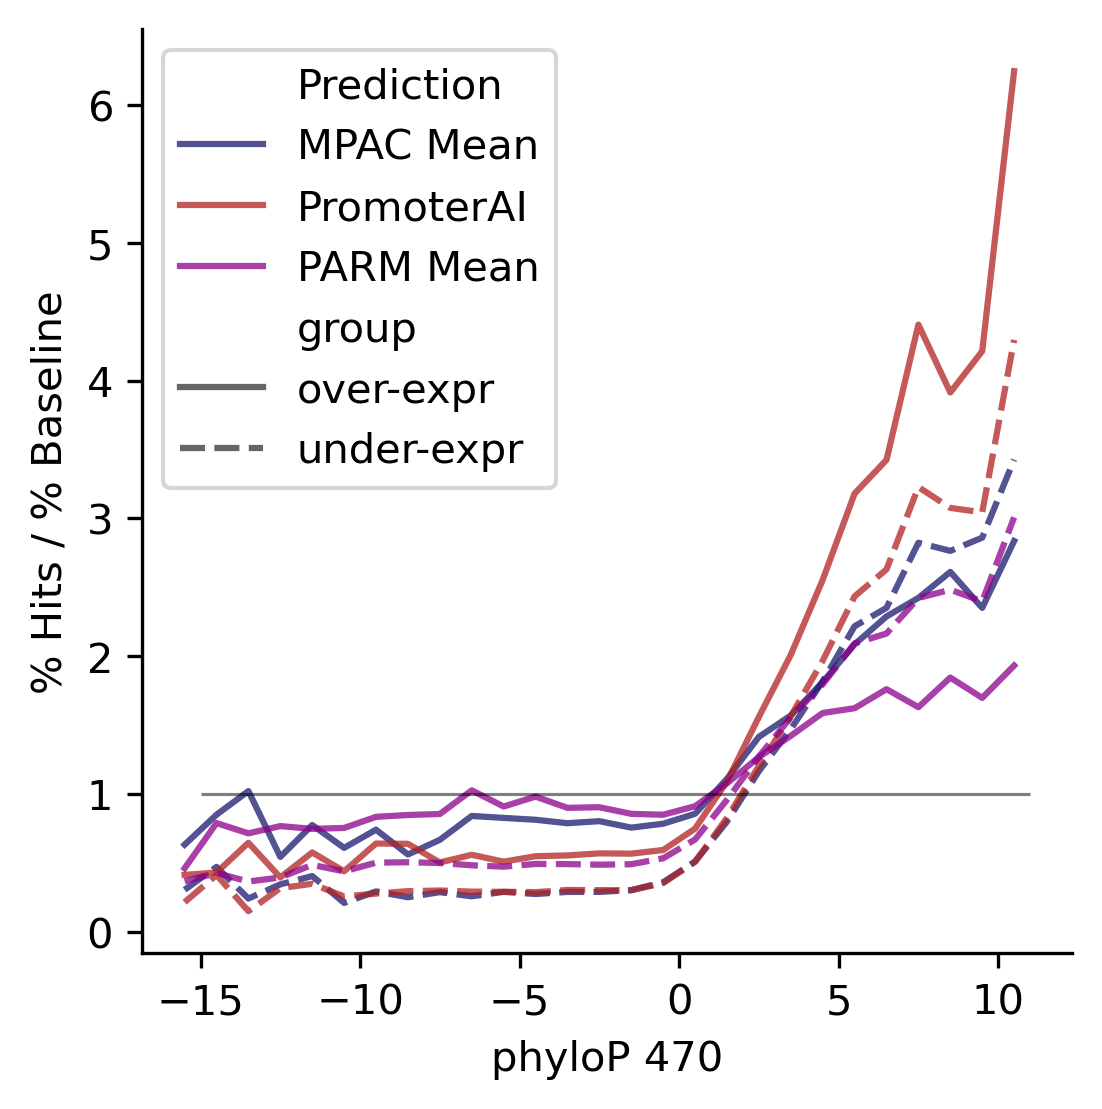

In [62]:
plt.figure(figsize=(4, 4), dpi=300)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
sns.lineplot(
    data=final_plot_df,
    x='phylo_mid',
    y='hit_ratio',
    hue='Prediction',        # Color by Over/Under
    style='group', # Dash/Solid by Model
    palette=palette,
    linewidth=1.5,
    alpha=0.75
)
plt.xlabel('phyloP 470')
plt.ylabel('% Hits / % Baseline')
plt.hlines(y=1, xmin=-15, xmax=max(bins470), color='k', linestyles='solid', alpha=0.5, linewidth=0.75)
sns.despine()
plt.title('', loc = 'left')
plt.savefig('plots/hits_by_phyloP_ratio_v2.pdf')